<a href="https://colab.research.google.com/github/Saputoa21/Applied_ML_Spoiler_Detection_Group_Project_2025/blob/main/Bert_base_cased_Spoiler_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformers

Models used:

* Bert base cased(Arina): https://huggingface.co/google-bert/bert-base-cased
* RoBERTa base (Milica): https://huggingface.co/FacebookAI/roberta-base
* Distilbert base cased (Anastasiya): https://huggingface.co/distilbert/distilbert-base-cased
* ... (Juliana)


## Pipeline form Hugging Face

In [ ]:
from transformers import pipeline, BertModel

# Text Classification:
classifier = pipeline("text-classification", model="bert-base-cased")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Device set to use cpu


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# pickin up one review

import pandas as pd
import numpy as np

csv_path = '/content/drive/MyDrive/combined_df_exploded_1.csv'
combined_df_exploded = pd.read_csv(csv_path)

# Preview the data
combined_df_exploded.head()


,review_date,movie_id,user_id,is_spoiler,review_text,rating_x,review_summary,plot_summary,duration,genre,rating_y,release_date,plot_synopsis
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
1,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,Chronicles the experiences of a formerly succe...,2h 22min,Drama,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
2,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
3,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,Chronicles the experiences of a formerly succe...,2h 22min,Drama,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."
4,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film,Chronicles the experiences of a formerly succe...,2h 22min,Crime,9.3,1994-10-14,"In 1947, Andy Dufresne (Tim Robbins), a banker..."


In [ ]:
test_review = combined_df_exploded['review_text'][0]
classifier(test_review, truncation=True)

[{'label': 'LABEL_1', 'score': 0.5224579572677612}]

## Bert base cased


### Loading the Model

In [ ]:
!pip install transformers
!pip install datasets
!pip install evaluate
# !pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.6 MB/s eta 0:00:00


In [ ]:
import torch
print(torch.__version__)

2.6.0+cu124


In [ ]:
from transformers import BertTokenizer, BertModel

In [ ]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
from transformers import BertTokenizer, AutoModelForSequenceClassification

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

# Since the model cannot classify  logits
bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-cased', num_labels=2)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
print(bert_tokenizer)

BertTokenizer(name_or_path='bert-base-cased', vocab_size=28996, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [ ]:
print(bert_model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
input_str = "Spoiler alert!"

input_tokens = bert_tokenizer.tokenize(input_str)
print(f"Tokens of the input sequence: {input_tokens}")

input_ids = bert_tokenizer.convert_tokens_to_ids(input_tokens)
print(f"IDs assigned to the intput sequence: {input_ids}")

decoded = bert_tokenizer.decode(input_ids)
print(decoded)

model_inputs = bert_tokenizer("Spoiler alert!", return_tensors="pt")
print(model_inputs)

Tokens of the input sequence: ['S', '##po', '##iler', 'alert', '!']
IDs assigned to the intput sequence: [156, 5674, 25614, 10427, 106]
Spoiler alert!
{'input_ids': tensor([[  101,   156,  5674, 25614, 10427,   106,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}


### Loading Metrics

In [ ]:
!pip install transformers
!pip install datasets
!pip install evaluate
import evaluate

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
f1_metric = evaluate.load("f1")
recall_metric = evaluate.load('recall')

matthews_metric = evaluate.load("matthews_correlation")

In [ ]:
print(accuracy_metric.description)


Accuracy is the proportion of correct predictions among the total number of cases processed. It can be computed with:
Accuracy = (TP + TN) / (TP + TN + FP + FN)
 Where:
TP: True positive
TN: True negative
FP: False positive
FN: False negative



In [ ]:
print(precision_metric.description)


Precision is the fraction of correctly labeled positive examples out of all of the examples that were labeled as positive. It is computed via the equation:
Precision = TP / (TP + FP)
where TP is the True positives (i.e. the examples correctly labeled as positive) and FP is the False positive examples (i.e. the examples incorrectly labeled as positive).



In [ ]:
print(f1_metric.description)


The F1 score is the harmonic mean of the precision and recall. It can be computed with the equation:
F1 = 2 * (precision * recall) / (precision + recall)



In [ ]:
print(recall_metric.description)


Recall is the fraction of the positive examples that were correctly labeled by the model as positive. It can be computed with the equation:
Recall = TP / (TP + FN)
Where TP is the true positives and FN is the false negatives.



In [ ]:
print(matthews_metric.description)


Compute the Matthews correlation coefficient (MCC)

The Matthews correlation coefficient is used in machine learning as a
measure of the quality of binary and multiclass classifications. It takes
into account true and false positives and negatives and is generally
regarded as a balanced measure which can be used even if the classes are of
very different sizes. The MCC is in essence a correlation coefficient value
between -1 and +1. A coefficient of +1 represents a perfect prediction, 0
an average random prediction and -1 an inverse prediction.  The statistic
is also known as the phi coefficient. [source: Wikipedia]



### Loading the dataset for the model

In [ ]:
from datasets import load_dataset, DatasetDict, Dataset
from transformers import DataCollatorWithPadding

In [ ]:
#the file was already iploaded in the previous step
#import pandas as pd

#csv_path = '/content/drive/MyDrive/combined_df_exploded_1.csv'
#combined_df_exploded = pd.read_csv(csv_path)

# Preview the data
#combined_df_exploded.head()

In [ ]:
#for training we need to remove unnecessary columns from the dataset
combined_df_exploded_cleaned = combined_df_exploded[['review_text', 'is_spoiler']]

combined_df_exploded_cleaned.head()

,review_text,is_spoiler
0,"In its Oscar year, Shawshank Redemption (writt...",True
1,"In its Oscar year, Shawshank Redemption (writt...",True
2,The Shawshank Redemption is without a doubt on...,True
3,The Shawshank Redemption is without a doubt on...,True
4,I believe that this film is the best story eve...,True


In [ ]:
combined_df_exploded_cleaned['is_spoiler'].value_counts()


,count
is_spoiler,
False,152888
True,52416


In [ ]:
#it was used here just to check how the mixed reviews are shown, but not necessary to use because we do it later before splitting dataset
#combined_df_exploded_cleaned = combined_df_exploded[['review_text', 'is_spoiler']].sample(frac=1, random_state=42).reset_index(drop=True)
#combined_df_exploded_cleaned.head(10)

In [ ]:
#rename columns into 'text' and 'label'
combined_df_exploded_cleaned = combined_df_exploded_cleaned.rename(columns={'review_text': 'text', 'is_spoiler': 'label'})

#change True and False to 1 and 0
combined_df_exploded_cleaned['label'] = combined_df_exploded_cleaned['label'].astype(int)

combined_df_exploded_cleaned.head()

,text,label
0,"In its Oscar year, Shawshank Redemption (writt...",1
1,"In its Oscar year, Shawshank Redemption (writt...",1
2,The Shawshank Redemption is without a doubt on...,1
3,The Shawshank Redemption is without a doubt on...,1
4,I believe that this film is the best story eve...,1


### Splitting the dataset

In [ ]:
# convert pandas dataframe to Hugging Face Dataset
#spoiler_dataset = Dataset.from_pandas(combined_df_exploded_cleaned)

In [ ]:
#print(spoiler_dataset)

In [ ]:
# Just take the first 100 tokens for speed on CPU
#def truncate(example):
#    return {
#        'text': " ".join(example['text'].split()[:100]),
#        'label': example['label']
#    }

In [ ]:
# Take 128 random examples for train and 32 validation
#small_spoiler_dataset = DatasetDict(
#    train=spoiler_dataset.shuffle(seed=24).select(range(128)).map(truncate),
#    val=spoiler_dataset.shuffle(seed=24).select(range(128, 160)).map(truncate),
#    test=spoiler_dataset.shuffle(seed=24).select(range(128, 160)).map(truncate))

In [ ]:
#print(small_spoiler_dataset)

In [ ]:
#small_spoiler_dataset['train'][0]

In [ ]:
#we doo this in order to balance the dataset (so that we don't have too many 0 class examples)

import pandas as pd
from datasets import Dataset, DatasetDict

df = combined_df_exploded_cleaned.copy()

def truncate_text(text):
    return " ".join(text.split()[:100])
df["text"] = df["text"].apply(truncate_text)

# 128 for each class in train
label_0 = df[df["label"] == 0].sample(n=128, random_state=42)
label_1 = df[df["label"] == 1].sample(n=128, random_state=42)
train_df = pd.concat([label_0, label_1]).sample(frac=1, random_state=42)

label_0_rest = df[df["label"] == 0].drop(label_0.index)
label_1_rest = df[df["label"] == 1].drop(label_1.index)

# 32 for validation
val_label_0 = label_0_rest.sample(n=32, random_state=43)
val_label_1 = label_1_rest.sample(n=32, random_state=43)
val_df = pd.concat([val_label_0, val_label_1]).sample(frac=1, random_state=43)

label_0_rest = label_0_rest.drop(val_label_0.index)
label_1_rest = label_1_rest.drop(val_label_1.index)

# 32 for test
test_label_0 = label_0_rest.sample(n=32, random_state=44)
test_label_1 = label_1_rest.sample(n=32, random_state=44)
test_df = pd.concat([test_label_0, test_label_1]).sample(frac=1, random_state=44)

# DatasetDict
small_spoiler_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "val": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
})



In [ ]:
from transformers import AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

def tokenize_function(examples):
    return bert_tokenizer(examples["text"], padding=True, truncation=True)

In [ ]:
small_tokenized_dataset = small_spoiler_dataset.map(tokenize_function, batched=True, batch_size=16)
data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

In [ ]:
small_tokenized_dataset['train']['text'][0]

"In 1979, a little film hit theatres. You might have heard of it, it's called Alien. Ever seen it? You probably should. It's pretty good. Seriously, what am I talking about? It's Alien. Everyone has either seen or heard of this movie. Now, I don't see Ridley Scott as the master filmmaker some perceive him to be, but there are times when he got it very right. Alien is one of those times.In deep space, a ship called the Nostromo carrying mineral ore and seven crewmembers is bound for Earth. The crew are in hypersleep and all is well, that"

In [ ]:
small_tokenized_dataset['train'][0]

{'text': "In 1979, a little film hit theatres. You might have heard of it, it's called Alien. Ever seen it? You probably should. It's pretty good. Seriously, what am I talking about? It's Alien. Everyone has either seen or heard of this movie. Now, I don't see Ridley Scott as the master filmmaker some perceive him to be, but there are times when he got it very right. Alien is one of those times.In deep space, a ship called the Nostromo carrying mineral ore and seven crewmembers is bound for Earth. The crew are in hypersleep and all is well, that",
 'label': 1,
 'input_ids': [101,
  1130,
  2333,
  117,
  170,
  1376,
  1273,
  1855,
  16069,
  119,
  1192,
  1547,
  1138,
  1767,
  1104,
  1122,
  117,
  1122,
  112,
  188,
  1270,
  19637,
  119,
  10006,
  1562,
  1122,
  136,
  1192,
  1930,
  1431,
  119,
  1135,
  112,
  188,
  2785,
  1363,
  119,
  18725,
  117,
  1184,
  1821,
  146,
  2520,
  1164,
  136,
  1135,
  112,
  188,
  19637,
  119,
  6064,
  1144,
  1719,
  1562,
  

### One-Shot Training with Pipeline from Hugging Face

Just Classifier

In [ ]:
# pickin up one review
test_review = small_tokenized_dataset['train']['text'][0]
print(test_review)

In 1979, a little film hit theatres. You might have heard of it, it's called Alien. Ever seen it? You probably should. It's pretty good. Seriously, what am I talking about? It's Alien. Everyone has either seen or heard of this movie. Now, I don't see Ridley Scott as the master filmmaker some perceive him to be, but there are times when he got it very right. Alien is one of those times.In deep space, a ship called the Nostromo carrying mineral ore and seven crewmembers is bound for Earth. The crew are in hypersleep and all is well, that


In [ ]:
test_answer = small_tokenized_dataset['train']['label'][0]
print(test_answer)

1


In [ ]:
from transformers import pipeline

# Text Classification:
classifier = pipeline("text-classification")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
outputs = classifier(test_review)

print(outputs)

[{'label': 'POSITIVE', 'score': 0.9995580315589905}]


With model

In [ ]:
model_id = "bert-base-cased"
bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-cased', num_labels=2)
classifier = pipeline("text-classification", model=model_id)



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


In [ ]:
preds = classifier(test_review, return_all_scores=True)

print(preds)

/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


[[{'label': 'LABEL_0', 'score': 0.49772411584854126}, {'label': 'LABEL_1', 'score': 0.5022758841514587}]]


### One shot traning with the model

In [ ]:
model_inputs = bert_tokenizer(test_review, return_tensors="pt")

model_outputs = bert_model(**model_inputs)

print(f'model outputs:{model_inputs}')

print(f'model outputs: {model_outputs}')

model outputs:{'input_ids': tensor([[  101,  1130,  2333,   117,   170,  1376,  1273,  1855, 16069,   119,
          1192,  1547,  1138,  1767,  1104,  1122,   117,  1122,   112,   188,
          1270, 19637,   119, 10006,  1562,  1122,   136,  1192,  1930,  1431,
           119,  1135,   112,   188,  2785,  1363,   119, 18725,   117,  1184,
          1821,   146,  2520,  1164,   136,  1135,   112,   188, 19637,   119,
          6064,  1144,  1719,  1562,  1137,  1767,  1104,  1142,  2523,   119,
          1986,   117,   146,  1274,   112,   189,  1267, 23013,  2796,  1112,
          1103,  3283, 13140,  1199, 25784,  1140,  1106,  1129,   117,  1133,
          1175,  1132,  1551,  1165,  1119,  1400,  1122,  1304,  1268,   119,
         19637,  1110,  1141,  1104,  1343,  1551,   119,  1130,  1996,  2000,
           117,   170,  2062,  1270,  1103,  1302, 22230,  1186,  4004, 10956,
         12327,  1105,  1978,  3039,  3263, 10615,  1116,  1110,  4930,  1111,
          2746,   119,  

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

# 1. Load sample from dataset
sample = small_tokenized_dataset['test'][0]  # or ['val'][0]

# 2. Extract label (must be tensor)
true_label = torch.tensor([sample['label']])

# 3. Prepare model input
model_inputs = {
    'input_ids': torch.tensor([sample['input_ids']]),
    'attention_mask': torch.tensor([sample['attention_mask']])
}

# 4. Run model (no gradient needed)
with torch.no_grad():
    outputs = bert_model(**model_inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1)

In [ ]:
# 5. Compute metrics
accuracy_score = accuracy_metric.compute(predictions=predictions, references=true_label)
precision_score = precision_metric.compute(predictions=predictions, references=true_label)
recall_score = recall_metric.compute(predictions=predictions, references=true_label)
f1_score = f1_metric.compute(predictions=predictions, references=true_label)
matthews_score = matthews_metric.compute(predictions=predictions, references=true_label)

print(f"True label: {true_label.item()} | Predicted: {predictions.item()}")
print(f"Accuracy: {accuracy_score}")
print(f"Precision: {precision_score}")
print(f"Recall: {recall_score}")
print(f"F1: {f1_score}")
print(f"Matthews Corellation: {matthews_score}")

True label: 1 | Predicted: 1
Accuracy: {'accuracy': 1.0}
Precision: {'precision': 1.0}
Recall: {'recall': 1.0}
F1: {'f1': 1.0}
Matthews Corellation: {'matthews_correlation': 0.0}


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


### Training

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# we add weights to improve the results
labels = small_tokenized_dataset['train']['label']
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)


tensor([1., 1.])


In [ ]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        global class_weights
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
import numpy as np
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification

bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-cased', num_labels=2)

arguments = TrainingArguments(
    output_dir="/content/drive/MyDrive/sample_cl_trainer",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=8,
    num_train_epochs=5,
    eval_strategy="epoch", # run validation at the end of each epoch
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to='none',
    seed=224
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision_metric.compute(predictions=predictions, references=labels)["precision"],
        "recall": recall_metric.compute(predictions=predictions, references=labels)["recall"],
        "f1": f1_metric.compute(predictions=predictions, references=labels)["f1"],
        "matthews_correlation": matthews_metric.compute(predictions=predictions, references=labels)["matthews_correlation"]}


trainer = WeightedTrainer(
    model=bert_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['val'],
    tokenizer=bert_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-38-1abe451a3722>:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


In [48]:
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time,Accuracy,Precision,Recall,F1,Matthews Correlation
1,0.639500,0.711164,0.003900,0.500000,0.500000,0.406250,0.448276,0.000000
2,0.468700,0.829820,0.003900,0.531250,0.550000,0.343750,0.423077,0.067420
3,0.357400,0.917840,0.003900,0.468750,0.461538,0.375000,0.413793,-0.063628
4,0.275300,1.033335,0.003900,0.531250,0.525000,0.656250,0.583333,0.064550
5,0.157200,1.006113,0.003900,0.468750,0.464286,0.406250,0.433333,-0.062994


TrainOutput(global_step=80, training_loss=0.38317483812570574, metrics={'train_runtime': 2982.3055, 'train_samples_per_second': 0.429, 'train_steps_per_second': 0.027, 'total_flos': 122478196270080.0, 'train_loss': 0.38317483812570574, 'epoch': 5.0})

In [49]:
# to se if the models predics always 0

from collections import Counter
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = preds.argmax(axis=1)
print(Counter(pred_labels))  # Count predicted classes

true_labels = small_tokenized_dataset['val']['label']
print(Counter(true_labels))  # Count actual classes

Counter({np.int64(0): 35, np.int64(1): 29})
Counter({1: 32, 0: 32})


In [51]:
from collections import Counter
import numpy as np

# Get predictions
preds = trainer.predict(small_tokenized_dataset['val']).predictions
pred_labels = np.argmax(preds, axis=1)

# Count how many of each label are predicted
print("Predicted label counts:", Counter(pred_labels))

# Compare with ground truth
true_labels = small_tokenized_dataset['val']['label']
print("True label counts:", Counter(true_labels))


Predicted label counts: Counter({np.int64(0): 35, np.int64(1): 29})
True label counts: Counter({1: 32, 0: 32})


<Axes: >

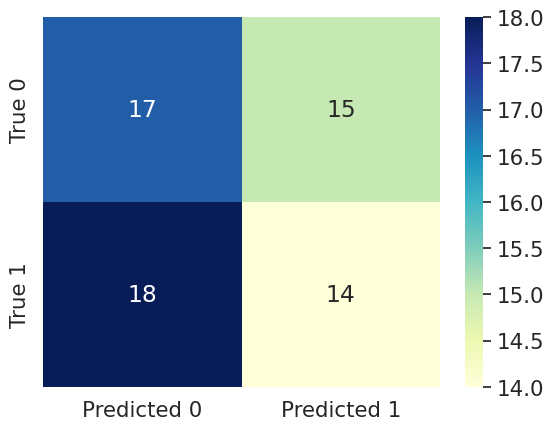

In [52]:
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sn

conf_mat = metrics.confusion_matrix(true_labels, pred_labels)
df_cm = pd.DataFrame(conf_mat, ["True 0","True 1"], ["Predicted 0","Predicted 1"])

sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='d', cmap="YlGnBu")

### Testing

In [2]:
fine_tuned_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/sample_cl_trainer/checkpoint-80") # Assuming checkpoint-80 is the last checkpoint

NameError: name 'AutoModelForSequenceClassification' is not defined

One review

In [54]:
model_inputs = bert_tokenizer(test_review, return_tensors="pt")
prediction = torch.argmax(fine_tuned_model(**model_inputs).logits)

print(["Non-Spoiler", "Spoiler"][prediction])

Spoiler


Test set

In [55]:
trainer = Trainer(
    model=fine_tuned_model,
    args=arguments,
    train_dataset=small_tokenized_dataset['train'],
    eval_dataset=small_tokenized_dataset['test'], #change to test for final step
    tokenizer=bert_tokenizer,  # Optional, only if needed
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

<ipython-input-55-2ce7f873e55d>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [56]:
trainer.evaluate(eval_dataset=small_tokenized_dataset['test'])

{'eval_loss': 1.0061126947402954,
 'eval_model_preparation_time': 0.0033,
 'eval_accuracy': 0.46875,
 'eval_precision': 0.4642857142857143,
 'eval_recall': 0.40625,
 'eval_f1': 0.43333333333333335,
 'eval_matthews_correlation': -0.0629940788348712,
 'eval_runtime': 36.743,
 'eval_samples_per_second': 1.742,
 'eval_steps_per_second': 0.109}